# 150. PyTorch 다중 분류 손실 함수 (Multi-Class Loss Functions)

## 다중 분류 손실 함수
    
<img src="https://gombru.github.io/assets/cross_entropy_loss/softmax_CE_pipeline.png" width=500 />

### `nn.CrossEntropyLoss`
- 내부적으로 `softmax` 함수를 포함
- 모델의 마지막 레이어에서 **Softmax를 적용하지 않고 logit만 출력**

### `nn.NLLLoss` (Negative Log Likelihood Loss)
- 입력으로 확률 분포가 필요
- 모델의 마지막 레이어에서 **LogSoftmax를 적용해야 함**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import load_wine

### 방법 1: nn.CrossEntropyLoss 함수 사용

In [2]:
# 이 텐서는 모델의 출력으로 볼 수 있으며, 각 요소는 특정 클래스에 속할 확률 또는 점수를 나타냅니다.
# 여기서는 10개의 다른 클래스에 대한 점수를 포함하고 있습니다.
x = torch.Tensor([[0.8982, 0.805, 0.6393, 0.9983, 0.5731, 0.0469, 0.556, 0.1476, 0.8404, 0.5544]])

# 주어진 샘플의 실제 클래스를 1번 클래스로 지정
y = torch.LongTensor([1])

In [3]:
# 크로스 엔트로피 손실 함수 생성 (Softmax + NLLLoss 포함)
cross_entropy_loss = torch.nn.CrossEntropyLoss()

# 예측값 x와 실제 레이블 y에 대해 손실 계산
loss = cross_entropy_loss(x, y)

# 손실값 출력
print(loss)

tensor(2.1438)


### 방법 2: nn.LogSoftmax + nn.NLLLoss

In [4]:
# LogSoftmax 함수 생성 (소프트맥스 적용 후 로그 값 반환)
log_softmax = torch.nn.LogSoftmax(dim=1)

# 입력 x에 대해 로그 소프트맥스 계산 (클래스별 로그 확률)
x_log = log_softmax(x)
x_log

tensor([[-2.0506, -2.1438, -2.3095, -1.9505, -2.3757, -2.9019, -2.3928, -2.8012,
         -2.1084, -2.3944]])

In [5]:
# torch.nn.NLLLoss()를 인스턴스화하고, 계산된 로그 소프트맥스 값(x_log)과
# 실제 레이블(y)을 사용하여 음의 로그 가능도 손실(Negative Log Likelihood Loss)을 계산합니다.
loss = nn.NLLLoss()(x_log, y)
print(loss)

tensor(2.1438)


## forward method의 반환값 비교

In [6]:
# nn.Module을 상속받아 사용자 정의 신경망 클래스를 정의합니다.
class Ex_NN(nn.Module):
    def __init__(self):
        super().__init__()
        # 첫 번째 선형 레이어를 정의합니다. 입력 차원은 2, 출력 차원은 8입니다.
        self.linear1 = nn.Linear(2, 8)
        # 두 번째 선형 레이어를 정의합니다. 입력 차원은 8, 출력 차원은 3입니다.
        self.linear2 = nn.Linear(8, 3)
        # LogSoftmax 활성화 함수를 정의합니다.
        self.log_softmax = nn.LogSoftmax(dim=1)

    def forward1(self, x):
        x = self.linear1(x)  # 입력 x를 첫 번째 선형 레이어에 통과시킵니다.
        x = self.linear2(x)  # 두 번째 선형 레이어에 통과시킵니다.
        # CrossEntropyLoss를 사용할 경우, 마지막에 log softmax를 사용하지 않습니다.
        return x

    def forward2(self, x):
        x = self.linear1(x)   # 입력 x를 첫 번째 선형 레이어에 통과시킵니다.
        x = self.linear2(x)   # 두 번째 선형 레이어에 통과시킵니다
        # NLLLoss를 사용할 경우, 마지막에 log softmax를 적용합니다.
        x = self.log_softmax(x)
        return x

# Ex_NN 모델 인스턴스 생성
model_example = Ex_NN()

# 입력 데이터 (3개의 샘플, 각 샘플은 2개의 특성값)
x = torch.FloatTensor([[20, 10],
                       [10, 30],
                       [10, 1]])

# 정답 레이블 (각 샘플의 클래스 인덱스)
y = torch.tensor([0, 2, 1])  # 첫 번째 샘플은 클래스 0, 두 번째는 2, 세 번째는 1

### CrossEntropyLoss 사용

In [7]:
loss = nn.CrossEntropyLoss()  # 크로스 엔트로피 손실 함수 정의
logits = model_example.forward1(x)    # 모델에 입력 x를 전달해 출력(logits) 계산
print(loss(logits, y))        # 손실값 출력

tensor(4.1985, grad_fn=<NllLossBackward0>)


In [8]:
print(logits)

tensor([[ 5.7245, -9.5634,  9.1657],
        [ 3.0017, -3.6463,  6.4480],
        [ 2.7884, -4.7759,  4.0703]], grad_fn=<AddmmBackward0>)


In [9]:
predicted_classes = torch.argmax(logits, axis=-1)
print("예측된 클래스:", predicted_classes)

예측된 클래스: tensor([2, 2, 2])


### Negative Log Likelihood Loss 사용

In [10]:
loss = nn.NLLLoss()  # 음의 로그 가능도 손실 함수 (NLLLoss) 정의
prob = model_example.forward2(x)  # 모델을 통해 LogSoftmax가 적용된 확률(probabilities) 얻기
print(loss(prob, y))  # 손실값 출력

tensor(4.1985, grad_fn=<NllLossBackward0>)


In [11]:
print(prob)

tensor([[ -3.4728, -18.7606,  -0.0315],
        [ -3.4777, -10.1258,  -0.0314],
        [ -1.5269,  -9.0912,  -0.2450]], grad_fn=<LogSoftmaxBackward0>)


In [12]:
predicted_classes = torch.argmax(prob, axis=-1)
print("예측된 클래스:", predicted_classes)

예측된 클래스: tensor([2, 2, 2])


In [13]:
# torch.max 함수 사용
max_values, max_indices = torch.max(prob, axis=-1)
print("최대 값들:", max_values)
print("최대 값의 인덱스들:", max_indices)

최대 값들: tensor([-0.0315, -0.0314, -0.2450], grad_fn=<MaxBackward0>)
최대 값의 인덱스들: tensor([2, 2, 2])


### 요약

1. **`nn.CrossEntropyLoss()`**: 
   - 내부적으로 LogSoftmax + NLLLoss를 포함
   - 모델 출력이 logits일 때 사용
   - 모델의 마지막 레이어에서 Softmax를 적용하지 않음

2. **`nn.NLLLoss()`**: 
   - 로그 확률을 입력으로 받음
   - 모델의 마지막 레이어에서 LogSoftmax를 적용해야 함

## 1. 데이터셋 준비

Wine Quality 데이터셋을 로드하고 전처리합니다.

In [14]:
# sklearn의 실제 Wine 데이터셋 로드
from sklearn.datasets import load_wine

"""sklearn의 실제 Wine 데이터셋을 로드합니다."""
# Wine 데이터셋 로드
wine_data = load_wine()

# 특성과 타겟 분리
features = wine_data.data
target = wine_data.target

# 특성 이름
feature_names = wine_data.feature_names

# DataFrame 생성
df = pd.DataFrame(features, columns=feature_names)
df['target'] = target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [15]:
print("Wine 데이터셋 정보:")
print(f"데이터 크기: {df.shape}")
print(f"특성 수: {df.shape[1] - 1}")
print(f"클래스 수: {df['target'].nunique()}")
print("\n클래스 분포:")
print(df['target'].value_counts().sort_index())

# 클래스 이름 정의 (sklearn의 실제 클래스 이름 사용)
class_names = wine_data.target_names
print(f"\n클래스 이름: {class_names}")

Wine 데이터셋 정보:
데이터 크기: (178, 14)
특성 수: 13
클래스 수: 3

클래스 분포:
target
0    59
1    71
2    48
Name: count, dtype: int64

클래스 이름: ['class_0' 'class_1' 'class_2']


## 2. 데이터 전처리 및 분할

데이터를 훈련용과 테스트용으로 나누고 정규화합니다.

In [16]:
# 특성과 타겟 분리
X = df.drop('target', axis=1).values
y = df['target'].values

print(f"특성 데이터 크기: {X.shape}")
print(f"타겟 데이터 크기: {y.shape}")

# 훈련/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"훈련 데이터 크기: {X_train.shape}")
print(f"테스트 데이터 크기: {X_test.shape}")

# 데이터 정규화 (StandardScaler 사용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n정규화 후 데이터 통계:")
print(f"훈련 데이터 평균: {X_train_scaled.mean():.4f}")
print(f"훈련 데이터 표준편차: {X_train_scaled.std():.4f}")

# PyTorch 텐서로 변환
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.LongTensor(y_test)

print(f"\nPyTorch 텐서 크기:")
print(f"X_train_tensor: {X_train_tensor.shape}")
print(f"y_train_tensor: {y_train_tensor.shape}")
print(f"X_test_tensor: {X_test_tensor.shape}")
print(f"y_test_tensor: {y_test_tensor.shape}")

특성 데이터 크기: (178, 13)
타겟 데이터 크기: (178,)
훈련 데이터 크기: (142, 13)
테스트 데이터 크기: (36, 13)

정규화 후 데이터 통계:
훈련 데이터 평균: 0.0000
훈련 데이터 표준편차: 1.0000

PyTorch 텐서 크기:
X_train_tensor: torch.Size([142, 13])
y_train_tensor: torch.Size([142])
X_test_tensor: torch.Size([36, 13])
y_test_tensor: torch.Size([36])


## 3. 신경망 모델 정의

초보자가 이해하기 쉽도록 간단한 구조로 모델을 정의합니다.

In [25]:
class WineClassifier(nn.Module):
    def __init__(self, input_size=13, hidden_size=32, num_classes=3):
        super(WineClassifier, self).__init__()
        
        # 은닉층
        self.layer = nn.Linear(input_size, hidden_size)
        
        # 출력층 (CrossEntropyLoss를 사용하므로 softmax 적용하지 않음)
        self.output_layer = nn.Linear(hidden_size, num_classes)
        
        # LogSoftmax 레이어 (NLLLoss 사용을 위해)
        self.log_softmax = nn.LogSoftmax(dim=1)
        
    def forward(self, x):
        """CrossEntropyLoss를 위한 forward (logits 출력)"""
        x = self.layer(x)
        x = F.relu(x)
        x = self.output_layer(x)
        return x

# 모델 인스턴스 생성
model = WineClassifier(
    input_size=13,      # Wine 데이터셋 특성 13개
    hidden_size=32,    # 은닉층 크기
    num_classes=3,      # 3개 클래스 (class_0, class_1, class_2)
)

print("모델 구조:")
print(model)

# 모델 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n총 파라미터 수: {total_params:,}")
print(f"훈련 가능한 파라미터 수: {trainable_params:,}")

# 모델 구조 시각화
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n각 레이어별 파라미터 수:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.numel():,} 파라미터")

모델 구조:
WineClassifier(
  (layer): Linear(in_features=13, out_features=32, bias=True)
  (output_layer): Linear(in_features=32, out_features=3, bias=True)
  (log_softmax): LogSoftmax(dim=1)
)

총 파라미터 수: 547
훈련 가능한 파라미터 수: 547

각 레이어별 파라미터 수:
layer.weight: 416 파라미터
layer.bias: 32 파라미터
output_layer.weight: 96 파라미터
output_layer.bias: 3 파라미터


## 4. 데이터로더 생성

PyTorch DataLoader를 사용하여 배치 단위로 데이터를 처리합니다.

In [26]:
# 데이터로더 생성
batch_size = 32

# 훈련 데이터로더
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 테스트 데이터로더
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"훈련 배치 수: {len(train_loader)}")
print(f"테스트 배치 수: {len(test_loader)}")

# 배치 샘플 확인
for batch_x, batch_y in train_loader:
    print(f"\n첫 번째 배치 크기:")
    print(f"입력 데이터: {batch_x.shape}")
    print(f"타겟 데이터: {batch_y.shape}")
    print(f"타겟 값들: {batch_y}")
    break

훈련 배치 수: 5
테스트 배치 수: 2

첫 번째 배치 크기:
입력 데이터: torch.Size([32, 13])
타겟 데이터: torch.Size([32])
타겟 값들: tensor([1, 1, 2, 2, 1, 2, 2, 2, 0, 2, 0, 1, 1, 2, 1, 0, 2, 0, 1, 0, 1, 1, 1, 0,
        2, 1, 2, 1, 1, 1, 0, 1])


## 5. 손실함수와 옵티마이저 설정

앞에서 배운 CrossEntropyLoss를 사용합니다.

In [27]:
# 손실함수: CrossEntropyLoss (다중 분류용)
criterion = nn.CrossEntropyLoss()

# 옵티마이저: Adam (학습률 0.001)
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 6. 모델 훈련

In [28]:
# 손실값과 정확도를 저장할 리스트 초기화
train_losses = []
train_accuracy = []

# 하이퍼파라미터 설정
num_epochs = 100

print("=== 와인 품질 분류 신경망 학습 시작 ===")

for epoch in range(num_epochs):
    # 학습 모드 설정
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    # 학습 루프
    for x, y in train_loader:
        # 순전파
        yhat = model(x)
        loss = criterion(yhat, y)
        
        # 역전파
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # 통계 업데이트
        train_loss += loss.item()
        _, predicted = torch.max(yhat.data, 1)
        train_correct += (predicted == y).sum().item()
        train_total += y.size(0)
    
    # 평균 계산
    avg_train_loss = train_loss / len(train_loader)
    train_acc = train_correct / train_total
    
    # 리스트에 저장
    train_losses.append(avg_train_loss)
    train_accuracy.append(train_acc)
    
    # 진행 상황 출력
    if (epoch + 1) % 10 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] - "
              f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}")

print(f"\n신경망 학습 완료! 총 {num_epochs} 에포크 실행")

=== 와인 품질 분류 신경망 학습 시작 ===
Epoch [  1/100] - Train Loss: 0.9493, Train Acc: 0.5563
Epoch [ 10/100] - Train Loss: 0.5813, Train Acc: 0.9296
Epoch [ 20/100] - Train Loss: 0.3067, Train Acc: 0.9577
Epoch [ 30/100] - Train Loss: 0.1665, Train Acc: 0.9789
Epoch [ 40/100] - Train Loss: 0.1083, Train Acc: 0.9930
Epoch [ 50/100] - Train Loss: 0.0734, Train Acc: 0.9930
Epoch [ 60/100] - Train Loss: 0.0533, Train Acc: 0.9930
Epoch [ 70/100] - Train Loss: 0.0403, Train Acc: 0.9930
Epoch [ 80/100] - Train Loss: 0.0311, Train Acc: 0.9930
Epoch [ 90/100] - Train Loss: 0.0275, Train Acc: 1.0000
Epoch [100/100] - Train Loss: 0.0201, Train Acc: 1.0000

신경망 학습 완료! 총 100 에포크 실행


## 7. 훈련 결과 시각화

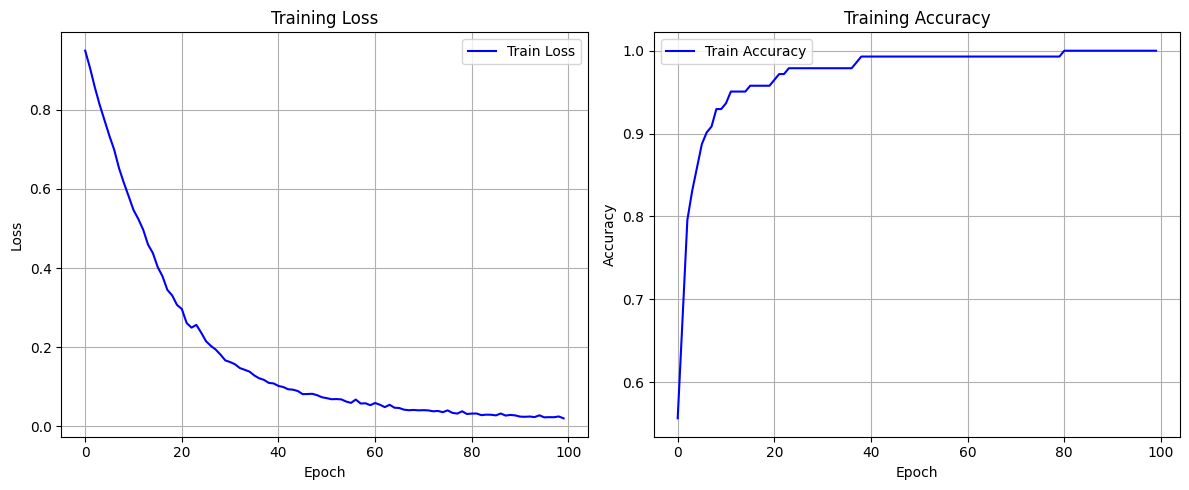

=== 최종 학습 성능 ===
최종 학습 손실: 0.0201
최종 학습 정확도: 1.0000


In [29]:
# 학습 과정 시각화
plt.figure(figsize=(12, 5))

# 서브플롯 1: 손실 곡선
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 서브플롯 2: 정확도 곡선
plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Train Accuracy', color='blue')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 최종 성능 요약
print("=== 최종 학습 성능 ===")
print(f"최종 학습 손실: {train_losses[-1]:.4f}")
print(f"최종 학습 정확도: {train_accuracy[-1]:.4f}")